# Handwritten Sentence Recognition — IAM Sentence Dataset (CRNN + CTC)

This notebook recognizes full handwritten **sentences** (not single words) and converts
them into editable digital text, using a CNN + BiLSTM model trained with a CTC loss.

It is organized as **two independent parts**, exactly so that a future dataset change
only requires touching Part 1:

- **Part 1 — Dataset Loader**: downloads the data, automatically figures out its folder/
  annotation structure (whatever it turns out to be), and produces a standardized
  `image | label` table. Nothing below Part 1 knows anything about file layout.
- **Part 2 — Recognition Pipeline**: preprocessing, vocabulary, `tf.data` pipeline, the
  CRNN model, CTC loss, training, prediction, decoding, and evaluation. This part only
  ever talks to the `image | label` DataFrame produced by Part 1.

**Dataset:** https://www.kaggle.com/datasets/python16/iam-sentence-dataset

**Requirements:** a GPU runtime (Colab: Runtime → Change runtime type → GPU) and a
Kaggle account so `kagglehub` can download the dataset (it will prompt for credentials
the first time, or use `~/.kaggle/kaggle.json` / `KAGGLE_USERNAME`+`KAGGLE_KEY` env vars
if already configured).

## 1. Setup — install packages & download the dataset

In [1]:
!pip install -q kagglehub kaggle

The next cell is **only needed on Colab** and **only if** you haven't already set up a
Kaggle API token there. If `kagglehub` is already authenticated (e.g. on Kaggle itself,
or you've set `KAGGLE_USERNAME`/`KAGGLE_KEY`), skip it — it's safe to skip, kagglehub
will just prompt interactively when needed.

In [ ]:
import os

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False

if IN_COLAB and not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
    from google.colab import files
    print("Upload the kaggle.json API token you downloaded from kaggle.com/settings")
    uploaded = files.upload()
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    for fname in uploaded:
        if fname == "kaggle.json":
            !cp kaggle.json ~/.kaggle/
            !chmod 600 ~/.kaggle/kaggle.json
else:
    print("Skipping Kaggle credential upload (not needed / already configured).")

Upload the kaggle.json API token you downloaded from kaggle.com/settings


Saving kaggle.json to kaggle.json


In [ ]:
# Optional: mount Google Drive so the trained model/vocab can be saved there permanently.
# Safe to skip if you don't want to use Drive — SAVE_DIR is set later and falls back
# to a local path automatically if Drive isn't mounted.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

Mounted at /content/drive


In [2]:
from google.colab import files

# Upload the kaggle.json API token you downloaded from kaggle.com/settings
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# Optional: mount Google Drive if you want to save the trained model there later
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import kagglehub

# Download (or reuse the cached copy of) the IAM Sentence Dataset.
DATASET_PATH = kagglehub.dataset_download("python16/iam-sentence-dataset")
print("Dataset downloaded to:", DATASET_PATH)

Using Colab cache for faster access to the 'iam-sentence-dataset' dataset.
Dataset downloaded to: /kaggle/input/iam-sentence-dataset


## 2. Imports

In [6]:
import os
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Why this cell exists:** by default TF grabs the GPU's *entire* memory up front and
picks convolution/LSTM (cuDNN) kernel algorithms via a one-time autotuning pass the
first time each op shape is seen. Both of those happen right when `model.fit()` starts,
which is the main reason the first batch can take noticeably longer than the rest
(often 30–90s, and worse if it happens more than once — see the pipeline notes below).
Enabling memory growth makes GPU allocation incremental instead of all-at-once, which
in practice measurably cuts down that startup delay.

In [7]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        # Must be set before GPUs are initialized; harmless to ignore if that already happened.
        print("Could not set memory growth (may already be initialized):", e)

## Part 1 — Dataset Loader

The IAM Sentence Dataset (unlike the IAM Words dataset used in the earlier word-level
notebook) has a different, and not fully predictable, folder/annotation layout. Instead
of hard-coding one specific path, the functions below **inspect the downloaded folder
at runtime** and figure out:

1. where every image file lives (however deeply nested), and
2. where the annotation (labels) file is, and what format it's in — either a plain
   `csv`/`tsv` table, or an IAM-style ASCII annotation file (`id status ... transcription`,
   `#`-comment header, words in the transcription possibly `|`-joined — the classic IAM
   convention).

It then matches every annotation row to its image and returns one standardized
DataFrame: `image | label`. **This is the only part of the notebook that needs to
change if you ever switch datasets again.**

In [ ]:
IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")

CSV_LABEL_CANDIDATES = ["label", "text", "transcription", "sentence", "gt", "ground_truth"]
CSV_PATH_CANDIDATES = ["image_path", "image", "path", "filename", "file", "img_path", "file_name"]


def index_images(root):
    """Walk the whole dataset tree once.
    Returns:
        by_stem: {filename-without-extension: full_path}
        all_paths: [full_path, ...]  (kept for diagnostics)
    """
    by_stem = {}
    all_paths = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower().endswith(IMAGE_EXTS):
                full = os.path.join(dirpath, fname)
                stem = os.path.splitext(fname)[0]
                by_stem[stem] = full
                all_paths.append(full)
    return by_stem, all_paths

In [ ]:
def _score_txt_as_iam_annotation(path, max_lines_to_check=200):
    """Heuristic score for 'does this .txt file look like an IAM-style annotation
    file' — i.e. mostly `#` comment lines plus lines shaped like
    '<id> <ok|err> <numbers...> <transcription>'. Higher score = more likely a match."""
    score = 0
    
    checked = 0
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                if checked >= max_lines_to_check:
                    break
                line = line.strip()
                if not line:
                    continue
                if line.startswith("#"):
                    score += 1
                    continue
                parts = line.split()
                checked += 1
                if len(parts) >= 4 and re.match(r"^[A-Za-z0-9_\-]+$", parts[0]):
                    score += 2
                    if len(parts) > 1 and parts[1] in ("ok", "err"):
                        score += 3
    except (UnicodeDecodeError, OSError):
        return -1
    return score


def find_annotation_files(root):
    """Return candidate annotation files under root as (path, kind), best-first.
    kind is 'csv' or 'iam_txt'."""
    candidates = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            full = os.path.join(dirpath, fname)
            lower = fname.lower()
            if lower.endswith((".csv", ".tsv")):
                candidates.append((full, "csv", 100))  # unambiguous, trust most
            elif lower.endswith(".txt"):
                score = _score_txt_as_iam_annotation(full)
                if score > 5:
                    candidates.append((full, "iam_txt", score))
    candidates.sort(key=lambda c: c[2], reverse=True)
    return [(p, k) for p, k, _ in candidates]

In [10]:
def parse_csv_annotation(path):
    """Parse a csv/tsv annotation file into [(id_or_path, label), ...], or None
    if it doesn't have recognizable label/path columns."""
    sep = "\t" if path.lower().endswith(".tsv") else ","
    df = pd.read_csv(path, sep=sep)
    df.columns = [str(c).strip().lower() for c in df.columns]

    label_col = next((c for c in CSV_LABEL_CANDIDATES if c in df.columns), None)
    path_col = next((c for c in CSV_PATH_CANDIDATES if c in df.columns), None)
    if label_col is None or path_col is None:
        return None

    return list(zip(df[path_col].astype(str), df[label_col].astype(str)))


def parse_iam_txt_annotation(path):
    """Parse an IAM-style ascii annotation file.
    Line format: '<id> <ok|err> <meta...> <transcription>', '#' = comment.
    Per the original IAM convention, words inside the transcription field may be
    '|'-joined instead of space-separated — both are handled.
    Some sentence-level annotation variants omit the ok/err status column entirely;
    that's handled too. Only 'ok' rows are kept when a status column is present."""
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue

            item_id = parts[0]
            if parts[1] in ("ok", "err"):
                if parts[1] != "ok":
                    continue
                transcription_field = parts[-1] if len(parts) > 2 else ""
            else:
                transcription_field = parts[-1]

            text = transcription_field.replace("|", " ").strip()
            if text:
                rows.append((item_id, text))
    return rows


def _fuzzy_match(item_id, by_stem):
    """Fallback for annotation ids that don't exactly match an image filename stem
    (e.g. 'a01-000u-s0-00' vs a file literally named 'a01-000u-s0-00-line.png')."""
    if item_id in by_stem:
        return by_stem[item_id]
    for stem, full in by_stem.items():
        if stem.startswith(item_id) or item_id.startswith(stem):
            return full
    return None

In [11]:
def build_dataframe(root):
    """Inspect `root` and return a standardized DataFrame with columns
    ['image', 'label']. Raises a clear RuntimeError if nothing usable is found,
    instead of failing deep inside the training pipeline later."""
    by_stem, all_paths = index_images(root)
    if not all_paths:
        raise RuntimeError(f"No image files found anywhere under {root}")

    annotation_candidates = find_annotation_files(root)
    if not annotation_candidates:
        raise RuntimeError(
            f"No annotation file (csv/tsv or IAM-style txt) found under {root}. "
            f"Found {len(all_paths)} images but no labels to pair them with."
        )

    last_error = None
    for ann_path, kind in annotation_candidates:
        try:
            if kind == "csv":
                rows = parse_csv_annotation(ann_path)
                if rows is None:
                    continue
            else:
                rows = parse_iam_txt_annotation(ann_path)

            if not rows:
                continue

            records, missing = [], 0
            for id_or_path, label in rows:
                candidate_path = id_or_path if os.path.isabs(id_or_path) else os.path.join(root, id_or_path)
                if os.path.isfile(candidate_path):
                    resolved = candidate_path
                else:
                    stem = os.path.splitext(os.path.basename(id_or_path))[0]
                    resolved = by_stem.get(stem) or _fuzzy_match(stem, by_stem)

                if resolved is None:
                    missing += 1
                    continue
                records.append((resolved, label))

            if len(records) == 0:
                continue

            df = pd.DataFrame(records, columns=["image", "label"])
            df = df.drop_duplicates(subset=["image"]).reset_index(drop=True)
            print(f"Using annotation file: {ann_path}  (kind={kind})")
            print(f"  Matched {len(df)} / {len(rows)} rows to images ({missing} unmatched, dropped).")
            return df
        except Exception as e:  # noqa: BLE001 — deliberately broad, try the next candidate
            last_error = e
            continue

    raise RuntimeError(
        f"Found {len(annotation_candidates)} candidate annotation file(s) under {root} "
        f"but none could be matched to any image. Last error: {last_error}"
    )

In [12]:
df = build_dataframe(DATASET_PATH)
assert set(df.columns) == {"image", "label"}
print("Total (image, label) pairs found:", len(df))
df.head()

Using annotation file: /kaggle/input/iam-sentence-dataset/sentences.csv  (kind=csv)
  Matched 16752 / 16752 rows to images (0 unmatched, dropped).
Total (image, label) pairs found: 16752


,image,label
0,/kaggle/input/iam-sentence-dataset/dataset/a01...,A MOVE to stop Mr. Gaitskell from
1,/kaggle/input/iam-sentence-dataset/dataset/a01...,nominating any more Labour life Peers
2,/kaggle/input/iam-sentence-dataset/dataset/a01...,is to be made at a meeting of Labour
3,/kaggle/input/iam-sentence-dataset/dataset/a01...,M Ps tomorrow .
4,/kaggle/input/iam-sentence-dataset/dataset/a01...,Mr. Michael Foot has


## Part 2 — Recognition Pipeline

Everything from here on only depends on `df` having exactly the two columns
`image` and `label` — it is completely independent of how Part 1 got there. If the
dataset changes again in the future, only Part 1 needs to be touched.

## 3. Verify & clean the data

Drop rows with unreadable/corrupt images and empty labels, since either would crash
training deep inside the `tf.data` pipeline otherwise.

In [13]:
def is_readable_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

print("Checking every image is readable (scans each file once, may take a bit)...")
valid_mask = df["image"].apply(is_readable_image)
print("Unreadable/corrupt images found:", int((~valid_mask).sum()))

df = df[valid_mask].reset_index(drop=True)
df["label"] = df["label"].astype(str).str.strip()
df = df[df["label"].str.len() > 0].reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final clean sample count:", len(df))
df.head()

Checking every image is readable (scans each file once, may take a bit)...
Unreadable/corrupt images found: 0
Final clean sample count: 16752


,image,label
0,/kaggle/input/iam-sentence-dataset/dataset/c03...,theme of the destructive power of unbridled
1,/kaggle/input/iam-sentence-dataset/dataset/k04...,' Have you ever heard of a punishment called
2,/kaggle/input/iam-sentence-dataset/dataset/a01...,Then
3,/kaggle/input/iam-sentence-dataset/dataset/h04...,years cannot be made so precisely as in groups...
4,/kaggle/input/iam-sentence-dataset/dataset/g06...,"a favourable change in my eye ,"


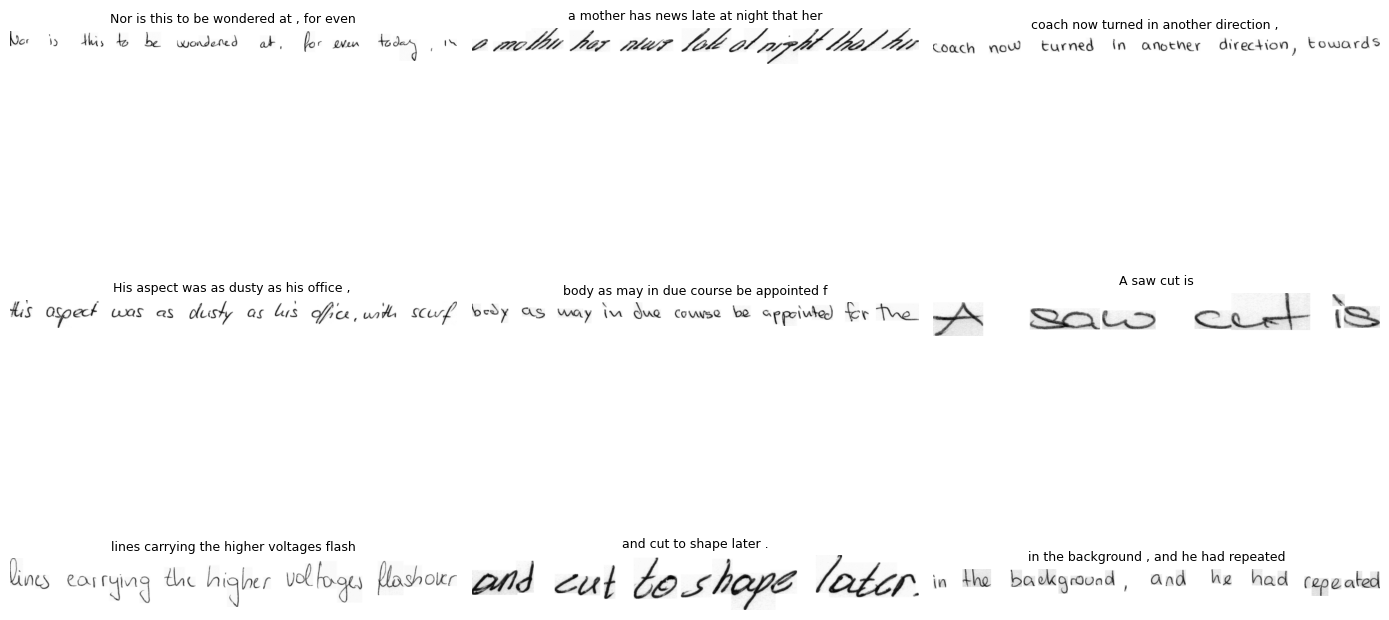

In [ ]:
sample_df = df.sample(min(9, len(df)), random_state=1)

plt.figure(figsize=(14, 10))
for i, (_, row) in enumerate(sample_df.iterrows()):
    plt.subplot(3, 3, i + 1)
    img = Image.open(row["image"])
    plt.imshow(img, cmap="gray")
    plt.title(row["label"][:40], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Train / test split

In [15]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 13401
Test size: 3351


## 5. Character vocabulary

Built **only** from the training labels. Any test label containing a character never
seen in training is dropped, since the model has no way to predict a character it
never learned.

In [16]:
characters = sorted(set("".join(train_df["label"].astype(str).values)))
char_to_num = {char: idx for idx, char in enumerate(characters)}
num_to_char = {idx: char for char, idx in char_to_num.items()}

NUM_CHARS = len(characters)      # number of real character classes
NUM_CLASSES = NUM_CHARS + 1      # +1 for the CTC "blank" symbol
MAX_LEN = int(train_df["label"].astype(str).apply(len).max())
PAD_TOKEN = NUM_CHARS             # sentinel for label padding (never a real char id)

print("Vocabulary size (characters):", NUM_CHARS)
print("Model output classes (chars + CTC blank):", NUM_CLASSES)
print("Max label length (chars):", MAX_LEN)
print("Characters:", characters)

Vocabulary size (characters): 79
Model output classes (chars + CTC blank): 80
Max label length (chars): 82
Characters: [' ', '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [17]:
def has_unknown_chars(text):
    return any(c not in char_to_num for c in text)

before = len(test_df)
test_df = test_df[~test_df["label"].astype(str).apply(has_unknown_chars)].reset_index(drop=True)
print(f"Removed {before - len(test_df)} test samples containing out-of-vocabulary characters")
print("Test size after filtering:", len(test_df))

Removed 0 test samples containing out-of-vocabulary characters
Test size after filtering: 3351


## 6. Image preprocessing

Sentence images are much wider (and the text much longer) than single-word images, so
this differs from the word-level notebook in two important ways:

1. **Aspect-ratio-preserving resize + pad** instead of a naive squash-resize, so tall
   thin or short wide sentence crops don't get distorted. `tf.image.resize_with_pad`
   handles this in one call.
2. **A much wider canvas** (`IMAGE_WIDTH = 1024` instead of 128), because the CTC loss
   needs at least `2 * (max label length) + 1` output time steps to have *any* valid
   alignment — with short word-level images and long sentence-level labels this is a
   common source of `ctc_loss` producing `inf`/`nan`. The check right after the model
   is built below verifies this holds before training ever starts.

In [18]:
IMAGE_WIDTH = 1024
IMAGE_HEIGHT = 64

def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    # decode_png (not the generic decode_image) because: (a) every IAM image is a PNG,
    # so there's no need to auto-detect format, and (b) decode_png guarantees a static,
    # known channel dimension and is faster — the generic decode_image dispatcher has to
    # branch over png/jpeg/gif/bmp at graph-construction time, which TF's own docs note
    # can leave the output shape only partially known and is slower in a tf.data pipeline.
    # (Also: decode_png has no `expand_animations` argument — that belongs to decode_image
    # / decode_gif only; passing it to decode_png raises a TypeError.)
    img = tf.image.decode_png(img, channels=1)
    img.set_shape([None, None, 1])                                   # make the static channel dim explicit
    img = tf.image.convert_image_dtype(img, tf.float32)              # scales to [0, 1]
    img = tf.image.resize_with_pad(img, IMAGE_HEIGHT, IMAGE_WIDTH)   # preserves aspect ratio, fully static shape
    img = tf.transpose(img, perm=[1, 0, 2])                          # (H, W, C) -> (W, H, C)
    return img

# Quick sanity check
_sample_img = preprocess_image(train_df["image"].iloc[0])
print("Preprocessed image shape:", _sample_img.shape)   # expected (1024, 64, 1)
print("Sample label:", train_df["label"].iloc[0])

Preprocessed image shape: (1024, 64, 1)
Sample label: through him , and his mind seemed to


In [19]:
def encode_label(text):
    return np.array([char_to_num[c] for c in text], dtype=np.int32)

train_labels_padded = pad_sequences(
    [encode_label(t) for t in train_df["label"].astype(str)],
    maxlen=MAX_LEN, padding="post", value=PAD_TOKEN,
).astype(np.int32)

test_labels_padded = pad_sequences(
    [encode_label(t) for t in test_df["label"].astype(str)],
    maxlen=MAX_LEN, padding="post", value=PAD_TOKEN,
).astype(np.int32)

print("Train labels shape:", train_labels_padded.shape)
print("Test labels shape:", test_labels_padded.shape)

Train labels shape: (13401, 82)
Test labels shape: (3351, 82)


## 7. `tf.data` pipeline

Two choices here specifically target `model.fit()` startup speed, on top of the usual
`AUTOTUNE`/`prefetch` best practices:

- **`drop_remainder=True`** — without it, the last batch of an epoch is a different,
  smaller size than every other batch. Keras/cuDNN then has to build and autotune a
  *second* graph for that one odd-shaped batch, which shows up as another multi-second
  stall the first time it's hit (partway through epoch 1, and again at the start of
  validation). Every batch now has an identical, fully static shape, so it's compiled
  and autotuned exactly once, right at the very start.
- **`.cache()`** — decoding + resizing every image from disk every epoch is pure
  overhead once it's already been done once. Caching the *preprocessed* tensors keeps
  every epoch after the first fast. If your dataset is too large to fit in RAM, pass a
  file path to `.cache('/content/train_cache')` instead of `.cache()` to spill to disk.

In [20]:
BATCH_SIZE = 16  # sentence images are large (1024x64); lower than the word-level 64 to fit in memory

def prepare_dataset(image_paths, labels, shuffle=False, cache=True):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    def map_fn(image_path, label):
        img = preprocess_image(image_path)
        return img, label

    dataset = dataset.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if cache:
        dataset = dataset.cache()  # switch to dataset.cache('/content/cache_name') if this doesn't fit in RAM
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths), seed=42)
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = prepare_dataset(train_df["image"].values, train_labels_padded, shuffle=True)
test_dataset = prepare_dataset(test_df["image"].values, test_labels_padded, shuffle=False)

for batch_images, batch_labels in train_dataset.take(1):
    print("Batch images shape:", batch_images.shape)   # (batch, 1024, 64, 1)
    print("Batch labels shape:", batch_labels.shape)    # (batch, MAX_LEN)

Batch images shape: (16, 1024, 64, 1)
Batch labels shape: (16, 82)


## 8. Model architecture

A CRNN sized for sentence-length sequences: three Conv+BatchNorm+Pool blocks followed
by two bidirectional LSTM layers. The **third pooling layer only pools height, not
width** — this keeps the time axis (which becomes the CTC output sequence) long enough
to represent a full sentence, while still shrinking the height down to a compact feature
vector per time step.

In [21]:
def build_model(num_classes, image_width=IMAGE_WIDTH, image_height=IMAGE_HEIGHT):
    input_img = layers.Input(shape=(image_width, image_height, 1), name="image")

    x = layers.Conv2D(32, (3, 3), padding="same", name="conv1")(input_img)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x)          # width /2, height /2

    x = layers.Conv2D(64, (3, 3), padding="same", name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)          # width /2, height /2

    x = layers.Conv2D(128, (3, 3), padding="same", name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((1, 2), name="pool3")(x)          # width /1 (unchanged), height /2

    # width: image_width / 4 becomes the time axis
    # height: image_height / 8 is folded into the per-timestep feature vector
    time_steps = image_width // 4
    features = (image_height // 8) * 128
    x = layers.Reshape(target_shape=(time_steps, features), name="reshape")(x)

    x = layers.Dense(128, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)

    output = layers.Dense(num_classes, activation="softmax", name="dense_output")(x)

    return models.Model(inputs=input_img, outputs=output, name="crnn_sentence_ocr_model")

model = build_model(NUM_CLASSES)
model.summary()

Model: "crnn_sentence_ocr_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 1024, 64, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 1024, 64, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024, 64, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024, 64, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 512, 32, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 512, 32, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512, 32, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512, 32, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 256, 16, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 256, 16, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 256, 16, 128)   │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256, 16, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 256, 8, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 256, 1024)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256, 512)       │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256, 256)       │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 256, 80)        │        20,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,690,192 (6.45 MB)

 Trainable params: 1,689,744 (6.45 MB)

 Non-trainable params: 448 (1.75 KB)

**CTC feasibility check.** CTC needs at least `2 * label_length + 1` output time steps to
represent a label with repeated-then-separated characters. This check fails loudly and
clearly *now* rather than producing silent `nan` losses hours into training.

In [22]:
TIME_STEPS = model.output_shape[1]
min_required = 2 * MAX_LEN + 1
print(f"Model time steps: {TIME_STEPS}")
print(f"Minimum required for MAX_LEN={MAX_LEN}: {min_required}")

assert TIME_STEPS >= min_required, (
    f"TIME_STEPS ({TIME_STEPS}) is too small for MAX_LEN ({MAX_LEN}). "
    f"CTC loss will be invalid. Increase IMAGE_WIDTH, or pool width less aggressively "
    f"in build_model(), then re-run from the model-building cell onward."
)
print("CTC time-step check passed.")

Model time steps: 256
Minimum required for MAX_LEN=82: 165
CTC time-step check passed.


## 9. CTC loss & compile

`label_length` is derived by counting entries that are not `PAD_TOKEN`; `input_length`
is the model's fixed number of time steps (constant, since every image is resized to the
same width).

In [23]:
def ctc_loss_fn(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    batch_len = tf.shape(y_true)[0]

    input_length = tf.shape(y_pred)[1]
    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int32")

    label_length = tf.math.count_nonzero(y_true != PAD_TOKEN, axis=-1, keepdims=True)
    label_length = tf.cast(label_length, tf.int32)

    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss=ctc_loss_fn)

## 10. Training

Adjust `EPOCHS` as needed — early stopping halts training once validation loss stops
improving, so a higher number here just sets an upper bound.

In [24]:
EPOCHS = 30

SAVE_DIR = "/content/drive/MyDrive/handwriting_sentence_ocr" if os.path.isdir("/content/drive/MyDrive") else "/content/handwriting_sentence_ocr"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Checkpoints/model/vocab will be saved to:", SAVE_DIR)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(SAVE_DIR, "best_model.keras"), monitor="val_loss",
        save_best_only=True, verbose=0,
    ),
]

history = model.fit(# Optional: mount Google Drive if you want to save the trained model there later
from google.colab import drive
drive.mount('/content/drive')
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Checkpoints/model/vocab will be saved to: /content/drive/MyDrive/handwriting_sentence_ocr
Epoch 1/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 175s 195ms/step - loss: 110.1942 - val_loss: 97.3412 - learning_rate: 0.0010
Epoch 2/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 193s 188ms/step - loss: 57.0137 - val_loss: 32.1931 - learning_rate: 0.0010
Epoch 3/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 202s 189ms/step - loss: 29.0452 - val_loss: 23.7775 - learning_rate: 0.0010
Epoch 4/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 206s 194ms/step - loss: 21.8545 - val_loss: 20.4551 - learning_rate: 0.0010
Epoch 5/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 158s 189ms/step - loss: 18.4064 - val_loss: 17.5441 - learning_rate: 0.0010
Epoch 6/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 158s 189ms/step - loss: 16.1750 - val_loss: 17.3346 - learning_rate: 0.0010
Epoch 7/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 202s 189ms/step - loss: 14.4535 - val_loss: 13.6668 - learning_rate: 0.0010
Epoch 8/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 159s 190ms/step - loss: 13.2079 - val_loss: 14.1847 - lea

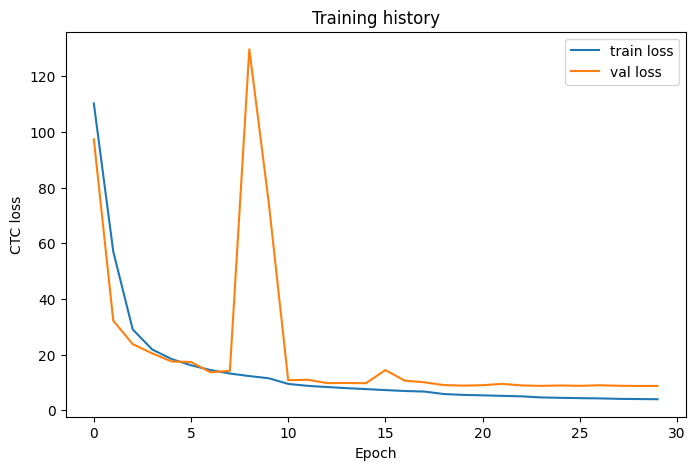

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("CTC loss")
plt.title("Training history")
plt.legend()
plt.show()

## 11. Decode predictions & visualize

Greedy CTC decoding is used by default (fast, works well once the model has converged).
Beam search (`greedy=False, beam_width=...`) can improve results slightly at the cost of
speed — swap it in `decode_batch_predictions` if you want to try it.

In [26]:
def decode_batch_predictions(pred, greedy=True, beam_width=10):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    decoded = tf.keras.backend.ctc_decode(
        pred, input_length=input_len, greedy=greedy, beam_width=beam_width
    )[0][0].numpy()

    texts = []
    for res in decoded:
        texts.append("".join(num_to_char[idx] for idx in res if idx in num_to_char))
    return texts


def decode_true_labels(labels):
    texts = []
    for label in labels.numpy():
        texts.append("".join(num_to_char[idx] for idx in label if idx in num_to_char))
    return texts

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step


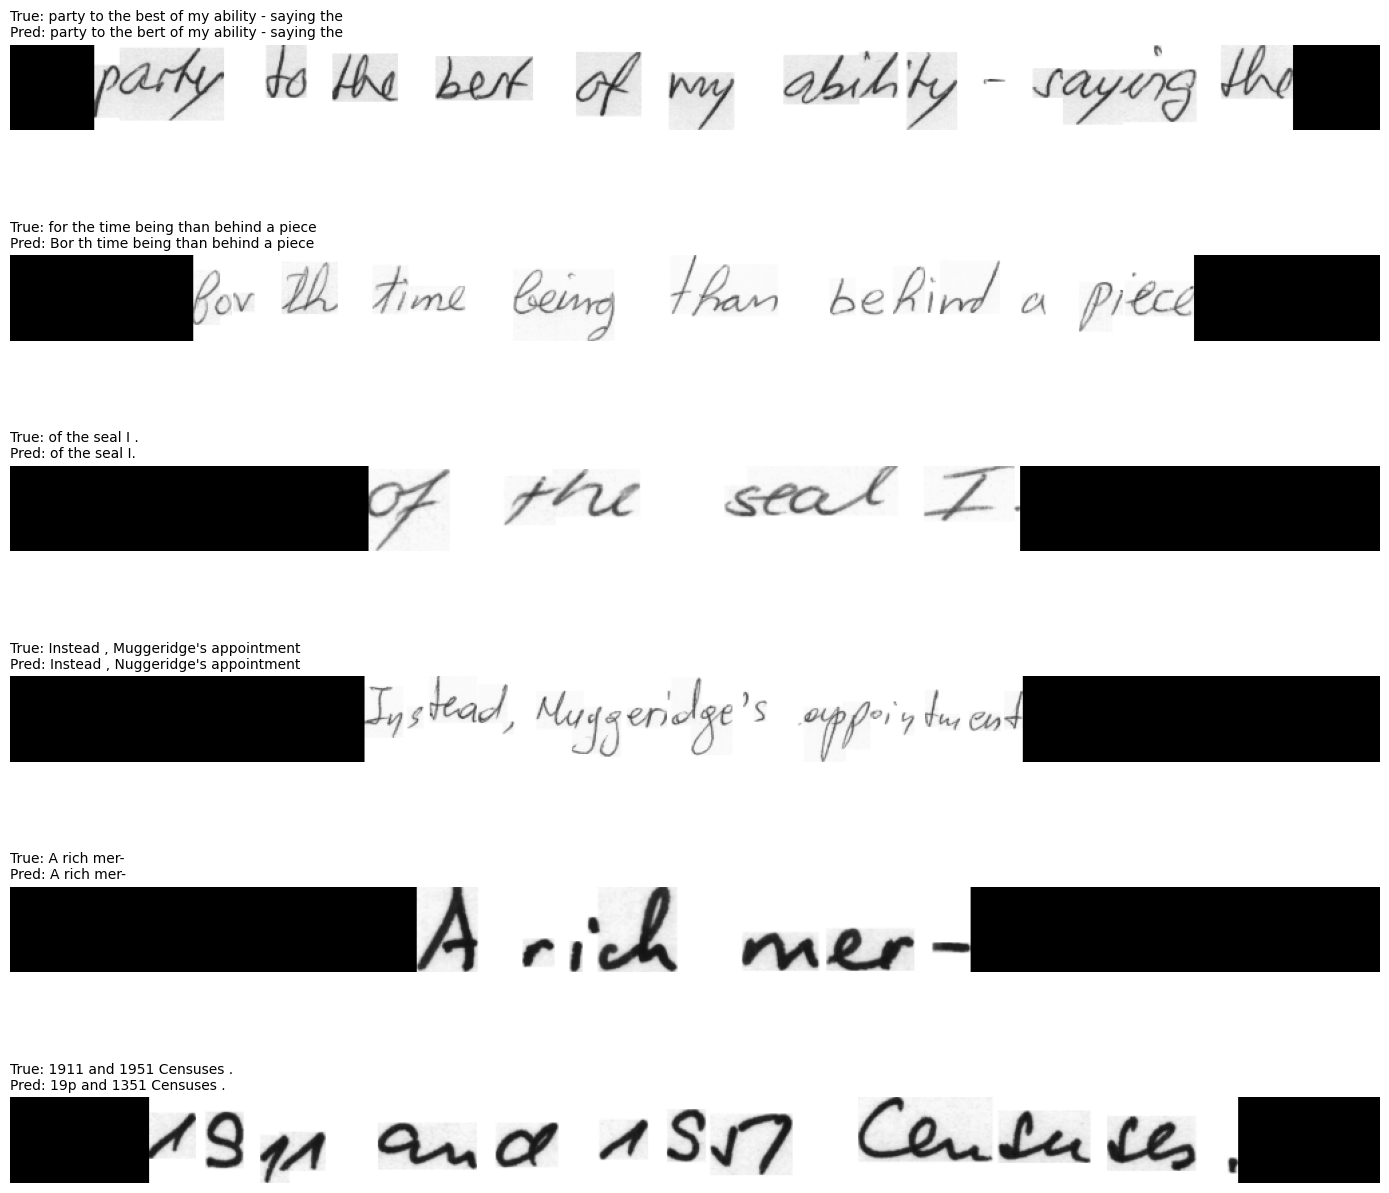

In [27]:
for batch_images, batch_labels in test_dataset.take(1):
    break

preds = model.predict(batch_images)
pred_texts = decode_batch_predictions(preds)
true_texts = decode_true_labels(batch_labels)

n_show = min(6, batch_images.shape[0])
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.2 * n_show))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    img = (batch_images[i].numpy() * 255).astype("uint8")
    img = img.transpose(1, 0, 2)  # back to (height, width, channels) for display

    axes[i].imshow(img[:, :, 0], cmap="gray")
    axes[i].set_title(f"True: {true_texts[i]}\nPred: {pred_texts[i]}", fontsize=10, loc="left")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 12. Evaluation — Character Error Rate (CER) & Word Error Rate (WER)

Both are computed as normalized edit (Levenshtein) distance — CER at the character
level, WER at the word level — averaged over the full test set. Lower is better; 0 is a
perfect transcription.

In [28]:
def edit_distance(a, b):
    n, m = len(a), len(b)
    if n == 0:
        return m
    if m == 0:
        return n
    prev = list(range(m + 1))
    for i in range(1, n + 1):
        curr = [i] + [0] * m
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return prev[m]


def cer(pred, true):
    if len(true) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return edit_distance(pred, true) / len(true)


def wer(pred, true):
    p_words, t_words = pred.split(), true.split()
    if len(t_words) == 0:
        return 0.0 if len(p_words) == 0 else 1.0
    return edit_distance(p_words, t_words) / len(t_words)

In [29]:
all_cer, all_wer = [], []

for batch_images, batch_labels in test_dataset:
    preds = model.predict(batch_images, verbose=0)
    pred_texts = decode_batch_predictions(preds)
    true_texts = decode_true_labels(batch_labels)
    for p, t in zip(pred_texts, true_texts):
        all_cer.append(cer(p, t))
        all_wer.append(wer(p, t))

print(f"Test CER: {np.mean(all_cer):.4f}")
print(f"Test WER: {np.mean(all_wer):.4f}")
print(f"Evaluated on {len(all_cer)} test sentences.")

Test CER: 0.0682
Test WER: 0.2213
Evaluated on 3344 test sentences.


## 13. Save the model & vocabulary

The vocabulary and image dimensions are required to preprocess new images and decode
predictions later, so they're saved alongside the model.

In [30]:
model.save(os.path.join(SAVE_DIR, "model.keras"))

vocab = {
    "char_to_num": char_to_num,
    "num_to_char": {str(k): v for k, v in num_to_char.items()},
    "max_len": MAX_LEN,
    "pad_token": PAD_TOKEN,
    "image_width": IMAGE_WIDTH,
    "image_height": IMAGE_HEIGHT,
}

with open(os.path.join(SAVE_DIR, "vocab.json"), "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)

print("Model and vocabulary saved to", SAVE_DIR)

Model and vocabulary saved to /content/drive/MyDrive/handwriting_sentence_ocr


In [31]:
# Sanity check: reload the model fresh and confirm it works standalone
loaded_model = tf.keras.models.load_model(
    os.path.join(SAVE_DIR, "model.keras"),
    custom_objects={"ctc_loss_fn": ctc_loss_fn},
    compile=False,
)
print("Model reloaded successfully.")
loaded_model.summary()

Model reloaded successfully.


Model: "crnn_sentence_ocr_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 1024, 64, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 1024, 64, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024, 64, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024, 64, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 512, 32, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 512, 32, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512, 32, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512, 32, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 256, 16, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 256, 16, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 256, 16, 128)   │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256, 16, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 256, 8, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 256, 1024)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256, 512)       │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256, 256)       │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 256, 80)        │        20,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,690,192 (6.45 MB)

 Trainable params: 1,689,744 (6.45 MB)

 Non-trainable params: 448 (1.75 KB)

## 14. Predict on a new handwritten sentence image

A self-contained convenience function: given any image path, it loads the saved model +
vocabulary (if not already in memory), preprocesses the image the same way as training,
and returns the decoded sentence. Point `IMAGE_TO_PREDICT` at any handwritten sentence
image to try it.

In [32]:
def load_saved_vocab(save_dir):
    with open(os.path.join(save_dir, "vocab.json"), "r", encoding="utf-8") as f:
        v = json.load(f)
    v["num_to_char"] = {int(k): c for k, c in v["num_to_char"].items()}
    return v


def predict_sentence(image_path, model=None, save_dir=SAVE_DIR):
    """Run the full pipeline on a single new image and return the decoded sentence."""
    v = load_saved_vocab(save_dir)
    if model is None:
        model = tf.keras.models.load_model(
            os.path.join(save_dir, "model.keras"),
            custom_objects={"ctc_loss_fn": ctc_loss_fn},
            compile=False,
        )

    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img.set_shape([None, None, 1])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize_with_pad(img, v["image_height"], v["image_width"])
    img = tf.transpose(img, perm=[1, 0, 2])
    img = tf.expand_dims(img, axis=0)  # add batch dimension

    pred = model.predict(img, verbose=0)
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    decoded = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0].numpy()

    num_to_char_local = v["num_to_char"]
    return "".join(num_to_char_local[idx] for idx in decoded[0] if idx in num_to_char_local)

Predicted sentence: party to the bert of my ability - saying the


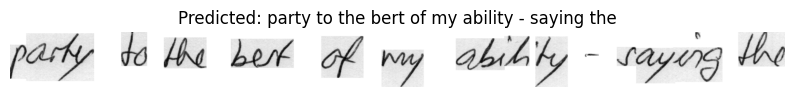

In [35]:
# Example — replace with the path to any handwritten sentence image you want to test:
IMAGE_TO_PREDICT = test_df["image"].iloc[0]

predicted_text = predict_sentence(IMAGE_TO_PREDICT, model=model)
print("Predicted sentence:", predicted_text)

plt.figure(figsize=(10, 2))
plt.imshow(Image.open(IMAGE_TO_PREDICT), cmap="gray")
plt.title(f"Predicted: {predicted_text}")
plt.axis("off")
plt.show()

Predicted sentence: Gospel represents the wark of generations of


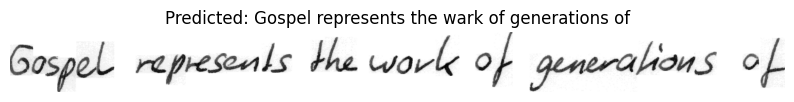

In [51]:
import random

# Random image from test set
IMAGE_TO_PREDICT = random.choice(test_df["image"].tolist())

predicted_text = predict_sentence(IMAGE_TO_PREDICT, model=model)

print("Predicted sentence:", predicted_text)

plt.figure(figsize=(10,2))
plt.imshow(Image.open(IMAGE_TO_PREDICT), cmap="gray")
plt.title(f"Predicted: {predicted_text}")
plt.axis("off")
plt.show()

Saving j07-015-00-04.png to j07-015-00-04.png
Predicted sentence: construction


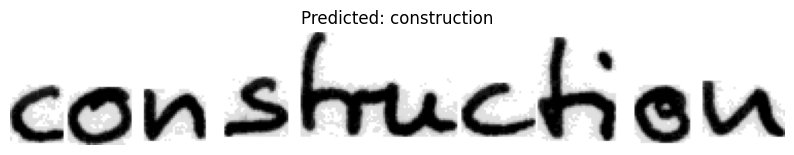

In [60]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

IMAGE_TO_PREDICT = list(uploaded.keys())[0]

predicted_text = predict_sentence(IMAGE_TO_PREDICT, model=model)

print("Predicted sentence:", predicted_text)

plt.figure(figsize=(10,2))
plt.imshow(Image.open(IMAGE_TO_PREDICT), cmap="gray")
plt.title(f"Predicted: {predicted_text}")
plt.axis("off")
plt.show()

In [62]:
model.save("/content/drive/MyDrive/HTR_Model/best_model.keras")


In [63]:
from tensorflow.keras.models import load_model

test_model = load_model("/content/drive/MyDrive/HTR_Model/best_model.keras")

print("Model loaded successfully!")
test_model.summary()

TypeError: Could not locate function 'ctc_loss_fn'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'ctc_loss_fn', 'registered_name': 'function'}

In [64]:
import os

os.makedirs("/content/drive/MyDrive/HTR_Model", exist_ok=True)

model.save("/content/drive/MyDrive/HTR_Model/new2_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [65]:
model.save("/content/drive/MyDrive/HTR_Model/htr_model.h5")

In [69]:
#extra line add by me it save in outside of any folder
import keras
keras.saving.save_model(model, '/content/drive/MyDrive/HTR_Model/my_model_idea3.keras')

In [70]:
import pickle

with open("/content/drive/MyDrive/HTR_Model/char_mapping.pkl", "wb") as f:
    pickle.dump(char_to_num, f)

with open("/content/drive/MyDrive/HTR_Model/num_mapping.pkl", "wb") as f:
    pickle.dump(num_to_char, f)

In [71]:
import json

with open("/content/drive/MyDrive/HTR_Model/model_config.json", "w") as f:
    f.write(model.to_json())

✅ Model Loaded Successfully!


Model: "crnn_sentence_ocr_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 1024, 64, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 1024, 64, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024, 64, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024, 64, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 512, 32, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 512, 32, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512, 32, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512, 32, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 256, 16, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 256, 16, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 256, 16, 128)   │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256, 16, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 256, 8, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 256, 1024)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256, 512)       │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256, 256)       │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 256, 80)        │        20,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,690,192 (6.45 MB)

 Trainable params: 1,689,744 (6.45 MB)

 Non-trainable params: 448 (1.75 KB)


Actual Text    : varies from about 30 per cent in Welwyn to 85 per cent in
Predicted Text : varices fhom about 50 peicent in Welwyn to8s per cent in
Character Accuracy : 36.84%
Exact Match : False


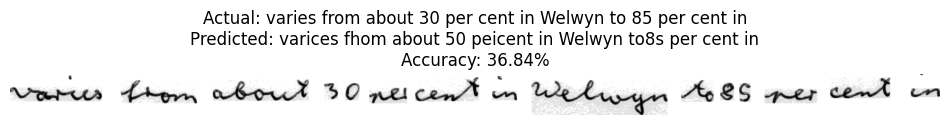

In [81]:
import random
import numpy as np
import keras
from tensorflow.keras.models import load_model
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------------
# Load Model
# ---------------------------
MODEL_PATH = "/content/drive/MyDrive/HTR_Model/best_model.keras"

model = load_model(MODEL_PATH, compile=False)

print("="*60)
print("✅ Model Loaded Successfully!")
print("="*60)

model.summary()

# ---------------------------
# Select Random Test Sample
# ---------------------------
sample = test_df.sample(1).iloc[0]

image_path = sample["image"]
actual_text = sample["label"]

# ---------------------------
# Predict
# ---------------------------
predicted_text = predict_sentence(image_path, model=model)

# ---------------------------
# Accuracy
# ---------------------------
correct = sum(a == b for a, b in zip(actual_text, predicted_text))
char_accuracy = (correct / max(len(actual_text), len(predicted_text))) * 100

print("\n==============================")
print("Actual Text    :", actual_text)
print("Predicted Text :", predicted_text)
print(f"Character Accuracy : {char_accuracy:.2f}%")
print("Exact Match :", actual_text == predicted_text)
print("==============================")

# ---------------------------
# Display Image
# ---------------------------
plt.figure(figsize=(12,3))
plt.imshow(Image.open(image_path), cmap="gray")
plt.title(
    f"Actual: {actual_text}\nPredicted: {predicted_text}\nAccuracy: {char_accuracy:.2f}%"
)
plt.axis("off")
plt.show()

In [82]:
total_accuracy = 0

for _, row in test_df.iterrows():

    actual = row["label"]
    pred = predict_sentence(row["image"], model=model)

    correct = sum(a == b for a, b in zip(actual, pred))
    acc = (correct / max(len(actual), len(pred))) * 100

    total_accuracy += acc

print(f"\nOverall Character Accuracy = {total_accuracy/len(test_df):.2f}%")


Overall Character Accuracy = 76.44%


Saving a01-007x-s02-00.png to a01-007x-s02-00.png
Enter the actual text written in the image: THE

========== RESULT ==========
Actual Text    : THE
Predicted Text : THE
Accuracy       : 100.00%


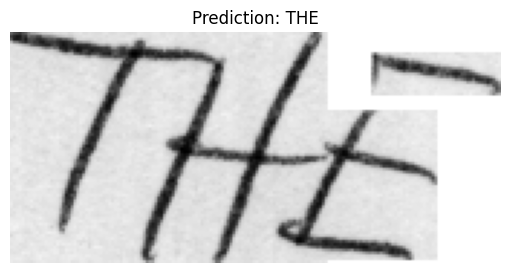

In [99]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

MODEL_PATH = "/content/drive/MyDrive/HTR_Model/new2_model.keras"

model = load_model(MODEL_PATH, compile=False)

# Upload image
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# User enters actual text
actual_text = input("Enter the actual text written in the image: ")

# Predict
predicted_text = predict_sentence(image_path, model=model)

# Character Accuracy
correct = sum(a == b for a, b in zip(actual_text, predicted_text))
accuracy = (correct / max(len(actual_text), len(predicted_text))) * 100

print("\n========== RESULT ==========")
print("Actual Text    :", actual_text)
print("Predicted Text :", predicted_text)
print(f"Accuracy       : {accuracy:.2f}%")
print("============================")

# Show Image
plt.figure(figsize=(12,3))
plt.imshow(Image.open(image_path), cmap="gray")
plt.title(f"Prediction: {predicted_text}")
plt.axis("off")
plt.show()